## Đề bài:
Sử dụng GridSearchCV để tìm tham số tối ưu cho cây quyết định (Decision Tree) trên tập dữ liệu Iris (load_iris() từ sklearn), sau đó đánh giá bằng Cross-Validation.

Yêu cầu:
a) Nạp tập dữ liệu Iris, hiển thị 5 dòng đầu và thống kê mô tả. 

b) Khởi tạo DecisionTreeClassifier. Định nghĩa lưới tham số: max_depth: [None, 3, 5, 10], min_samples_split: [2, 5, 10], criterion: ['gini', 'entropy'].

c) Chạy GridSearchCV với 5-fold Stratified CV. In tham số tốt nhất và độ chính xác tốt nhất.

d) Vẽ bản đồ nhiệt (heatmap) hiển thị độ chính xác trung bình cho mỗi tổ hợp max_depth × min_samples_split.

e) Dùng cross_val_score với mô hình tốt nhất, 10-fold CV. In accuracy từng fold và trung bình ± độ lệch chuẩn.


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

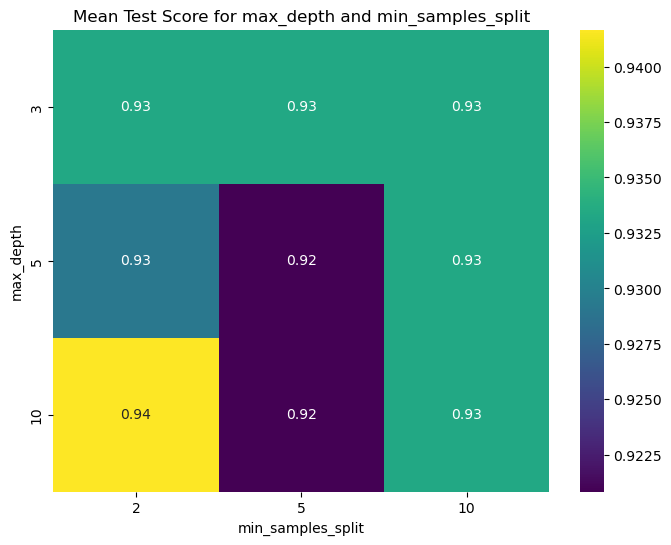

   Accuracy
0  1.000000
1  0.933333
2  1.000000
3  0.933333
4  0.933333
5  0.866667
6  0.933333
7  1.000000
8  1.000000
9  1.000000
Mean Standar DeviationL: 0.0442


In [ ]:
#nạp dữ liệu tập iris từ sk learn 
from sklearn.datasets import load_iris 
#import thư viện traintestsplit , decision tree , metrics, grid search cv và cross validation 
from sklearn.model_selection import train_test_split , GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier 

import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

#nạp dữ liệu tập iris_df
iris_df = pd.DataFrame(load_iris().data , columns = load_iris().feature_names)

#Hiển thị 5 dòng đầu 
print(iris_df.head())
#Thống kê mô tả dữ liệu 
print(iris_df.describe())

model_tree = DecisionTreeClassifier()
param_grid = {
    'max_depth': [None , 3 , 5 , 10],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2,5,10]
}
x = iris_df.values
y = load_iris().target

X_train , X_test , y_train , y_test = train_test_split(x,y , test_size= 0.2 , random_state = 42)
#5 stratified cv 
grid_search_decision_tree = GridSearchCV(estimator = model_tree , param_grid = param_grid , cv = 5, scoring= 'accuracy')
grid_search_decision_tree.fit(X_train , y_train)

best_parameters = grid_search_decision_tree.best_params_
best_score = grid_search_decision_tree.best_score_
print(f"Best Parameters: {best_parameters}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

#d) Vẽ bản đồ nhiệt (heatmap) hiển thị độ chính xác trung bình cho mỗi tổ hợp max_depth × min_samples_split.
results = pd.DataFrame(grid_search_decision_tree.cv_results_)
pivot_table = results.pivot_table(values = 'mean_test_score', index = 'param_max_depth', columns = 'param_min_samples_split')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot = True , cmap = 'viridis')
plt.title('Mean Test Score for max_depth and min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.show()

#dùng cross val score với mô hình tốt nhất từ grid search 
best_model = grid_search_decision_tree.best_estimator_
cross_val_scores =cross_val_score(best_model , x , y , cv = 10, scoring = 'accuracy')


cross_val_df = pd.DataFrame(cross_val_scores , columns = ['Accuracy'])
print(cross_val_df)
print(f"Mean Standar Deviation: {cross_val_scores.std().mean():.4f}")



### Kết quả : 
Ghi lại: tham số tốt nhất, accuracy tốt nhất, accuracy từng fold, trung bình ± độ lệch chuẩn
 


### Khung nhận xét phân tích : 
Yêu cầu: rõ ràng, có dẫn chứng số liệu, 3–5 câu.

## Bài B2: So sánh Mô hình Hồi quy Regularization (2 điểm)
(Session 2 + Session 3)
Đề bài:
Dùng make_regression(n_samples=300, n_features=20, n_informative=10, noise=20, random_state=42) để tạo tập dữ liệu. So sánh 5 mô hình hồi quy.

Yêu cầu:
a) Tạo tập dữ liệu, chia tập huấn luyện/kiểm tra theo tỷ lệ 80/20.

b) Huấn luyện 5 mô hình: (1) OLS (Linear Regression), (2) Ridge (α=1,0), (3) Lasso (α=0,1),
(4) Elastic Net (α=0,1, l1_ratio=0,7), (5) Polynomial Regression (degree=2) + Ridge.

c) Đánh giá mỗi mô hình bằng 5-fold CV: tính MAE, RMSE, R². Tạo bảng so sánh (DataFrame).

d) Vẽ biểu đồ thanh nhóm (grouped bar chart) so sánh R² của 5 mô hình.

e) Với Lasso và Elastic Net, in số đặc trưng bị loại bỏ (hệ số = 0). Kết luận mô hình phù hợp nhất.


In [11]:
#Dùng make_regression 
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
#import polynomial regression 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


X , y = make_regression(n_samples = 300 , n_features = 20 , n_informative= 10 , noise = 20 , random_state = 42)
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size= 0.2 , random_state = 42)

Linear_model = LinearRegression()
Linear_model.fit(X_train , y_train)

Ridge_model = Ridge(alpha = 1.0)
Ridge_model.fit(X_train , y_train)

Lasso_model = Lasso (alpha = 0.1)
Lasso_model.fit(X_train , y_train)

ElasticNet_model = ElasticNet(alpha = 0.1 , l1_ratio = 0.7)
ElasticNet_model.fit(X_train , y_train)

Polynomial_pipline = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 2)),
    ('Ridge', Ridge(alpha=1.0))
])
#Đánh giá mô hình
models = {
    'Linear-Regression': Linear_model, 
    'Ridge': Ridge_model,
    'Lasso': Lasso_model, 
    'ElasticNet': ElasticNet_model,
    'Polynomial-features': Polynomial_pipline
}
#Dùng cross val score để đánh giá từng mô hình và in ra MSE và RMSE và accuracy trung bình cho mỗi mô hình
for name , model in models.items():
    cross_val_scores = cross_val_score(model , X , y , cv = 5 , scoring = 'neg_mean_squared_error')
    mse_scores = -cross_val_scores
    rmse_scores = np.sqrt(mse_scores)
    accuracy_scores = cross_val_score(model , X , y , cv = 5 , scoring = 'r2')
    Analysis_df = pd.DataFrame({
        'Model': name,
        'MSE': mse_scores,
        'RMSE': rmse_scores,
        'R2 Score': accuracy_scores
    })
    print(f" \n {Analysis_df}")
    #print(f"model : {name} Mean Squared Error: {mse_scores:.4f} , Root Mean Squared Error: {rmse_scores:.4f} , R2 Score: {accuracy_scores:.4f}")

 
                Model         MSE       RMSE  R2 Score
0  Linear-Regression  438.214961  20.933585  0.979476
1  Linear-Regression  340.649935  18.456704  0.984000
2  Linear-Regression  549.461052  23.440586  0.961808
3  Linear-Regression  437.331608  20.912475  0.979629
4  Linear-Regression  396.009462  19.899986  0.981755
 
    Model         MSE       RMSE  R2 Score
0  Ridge  444.399328  21.080781  0.979187
1  Ridge  344.238759  18.553672  0.983831
2  Ridge  545.237686  23.350325  0.962101
3  Ridge  438.599897  20.942777  0.979570
4  Ridge  393.463754  19.835921  0.981872
 
    Model         MSE       RMSE  R2 Score
0  Lasso  440.307112  20.983496  0.979378
1  Lasso  343.965694  18.546312  0.983844
2  Lasso  540.507434  23.248816  0.962430
3  Lasso  435.431854  20.867004  0.979718
4  Lasso  389.851900  19.744668  0.982038
 
         Model         MSE       RMSE  R2 Score
0  ElasticNet  510.340823  22.590724  0.976098
1  ElasticNet  393.053816  19.825585  0.981538
2  ElasticNet  534.